In [1]:
from astropy.io import fits
from src.misc import *
from src.SPECTRUM import Spectrum
from src.FITSPECTRUM import FitSpectrum
from src.DP import DP
import matplotlib.pyplot as plt
import numpy as np
from astropy.table import Table
import pandas as pd

In [2]:
DP = DP()
dps_df, model_1comp_dps, left_2comp_dps, right_2comp_dps = DP.extract_fits_data('./catalogs/0310_dps.fits')

In [5]:
stellar_df = pd.read_csv('./catalogs/stellar_fits_catalog.csv')
stellar_df.head()

,TARGETID,MORPHTYPE,SERSIC,SHAPE_R,VD_SL,incl
0,39627739380056154,DEV,4.000000,1.577094,145.330002,44.629128
1,39627739380056197,REX,1.000000,0.969577,78.970001,0.000000
2,39627739380056420,SER,0.722487,2.256895,2.770000,79.009950
3,39627739380056564,REX,1.000000,1.275339,59.770000,0.000000
4,39627739380056768,EXP,1.000000,3.253861,72.139999,78.399880


In [6]:
dps_df = pd.merge(dps_df, stellar_df, on='TARGETID', how='left',validate='one_to_one')
dps_df.head()

,TARGETID,RA,DEC,Z,LOGM,LOGSFR,dv_r,dv_l,sigma_r,sigma_l,...,SII6716_rank,SII6731_rank,BPT_1comp,BPT_2comp,dp_count,MORPHTYPE,SERSIC,SHAPE_R,VD_SL,incl
0,39627739380056564,177.019318,-1.965308,0.323187,10.452706,0.941032,53.190807,-78.605568,50.497227,30.429680,...,7,9,256,512,2,REX,1.000000,1.275339,59.770000,0.000000
1,39627739380057506,177.058472,-1.984356,0.102379,10.324259,-0.880754,113.683365,-61.165852,41.490177,69.213905,...,4,6,256,512,1,REX,1.000000,0.781829,110.419998,0.000000
2,39627739380058467,177.097977,-1.888290,0.123931,10.402426,1.031611,88.310776,-28.034325,30.202024,51.832150,...,2,4,256,512,3,SER,1.144523,3.020720,86.650002,71.269295
3,39627739380060210,177.177948,-1.988386,0.238389,10.496312,0.039087,73.980766,-94.167976,57.098171,51.152431,...,2,4,256,512,2,SER,2.648419,1.265829,124.010002,47.433067
4,39627739380061198,177.216431,-1.948593,0.103277,9.514435,0.903058,87.747307,-73.973824,38.576229,50.498489,...,4,6,256,257,5,SER,1.779606,0.794439,100.040001,50.672260


In [7]:
print(len(dps_df))

25990


In [8]:
model_1comp_dps = model_1comp_dps[dps_df.index]
left_2comp_dps = left_2comp_dps[dps_df.index]
right_2comp_dps = right_2comp_dps[dps_df.index]

In [10]:
delta_dv = dps_df['dv_r'] - dps_df['dv_l']
resolution = c * 0.8 / (Halpha_rest*(1+dps_df['Z']))
sigma_r = np.sqrt(dps_df['sigma_r']**2 + resolution**2)
sigma_l = np.sqrt(dps_df['sigma_l']**2 + resolution**2)
dps_df['delta_dv'] = delta_dv
dps_df['width_ratio'] = sigma_l / sigma_r


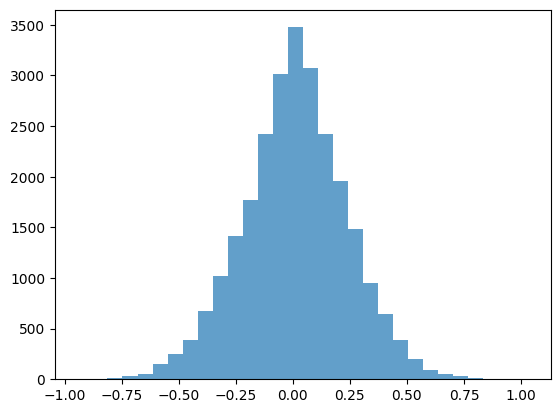

In [11]:
plt.hist(np.log10(dps_df['width_ratio']), bins=30, alpha=0.7, color='C0')
plt.show()

In [12]:
print(len(dps_df[np.log10(dps_df['width_ratio'])<0]))
print(len(dps_df[np.log10(dps_df['width_ratio'])>0]))

12326
13575


In [13]:
dps_df['flux_ratio'] = 0
for i in range(len(dps_df)):
    lam = desi_wavelength/(1+dps_df['Z'][i])
    left_shift = dps_df['dv_l'][i] / c * Halpha_rest[0]
    right_shift = dps_df['dv_r'][i] / c * Halpha_rest[0]

    left_flux = np.max(left_2comp_dps[i][(lam>(Halpha_rest[0]+left_shift-2)) & (lam<(Halpha_rest[0]+left_shift+2))])
    right_flux = np.max(right_2comp_dps[i][(lam>(Halpha_rest[0]+right_shift-2)) & (lam<(Halpha_rest[0]+right_shift+2))])

    if ((right_flux < 1) and (left_flux < 1)) or (dps_df['Halpha_dp'].iloc[i] is False):
        dps_df['flux_ratio'].iloc[i] = np.nan
    else:
        dps_df['flux_ratio'].iloc[i] = left_flux / right_flux


# dps_df['flux_ratio'] = 0
# for i in range(len(dps_df)):
#     lam = desi_wavelength/(1+dps_df['Z'][i])
#     left_shift = dps_df['dv_l'][i] / c * OIII_rest[1]
#     right_shift = dps_df['dv_r'][i] / c * OIII_rest[1]

#     left_flux = np.max(left_2comp_dps[i][(lam>(OIII_rest[1]+left_shift-2)) & (lam<(OIII_rest[1]+left_shift+2))])
#     right_flux = np.max(right_2comp_dps[i][(lam>(OIII_rest[1]+right_shift-2)) & (lam<(OIII_rest[1]+right_shift+2))])

#     if ((right_flux < 1) and (left_flux < 1)) or (dps_df['OIII5007_dp'].iloc[i] is False):
#         dps_df['flux_ratio'].iloc[i] = np.nan
#     else:
#         dps_df['flux_ratio'].iloc[i] = left_flux / right_flux



/var/folders/_b/sl_t4k5539781f29qf723b080000gn/T/ipykernel_38327/176573913.py:13: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  dps_df['flux_ratio'].iloc[i] = left_flux / right_flux
/var/folders/_b/sl_t4k5539781f29qf723b080000gn/T/ipykernel_

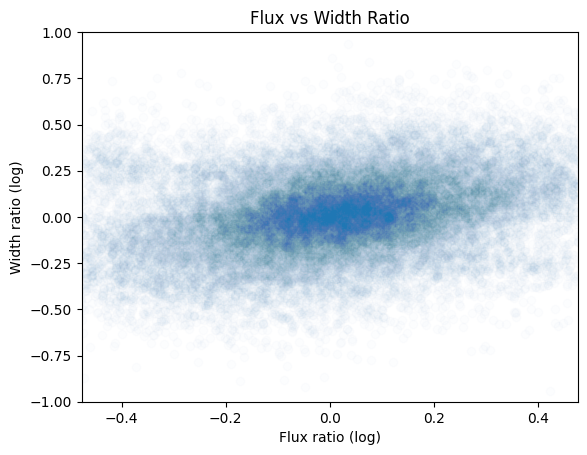

In [16]:
# plt.scatter(np.abs(np.log10(dps_df['flux_ratio'])), np.abs(np.log10(dps_df['width_ratio'])), alpha=.01)
plt.scatter((np.log10(dps_df['flux_ratio'])), (np.log10(dps_df['width_ratio'])), alpha=.01)
# plt.axvline(np.log10(1.3), color='k', linestyle='--', linewidth=1)
# plt.axhline(np.log10(1.5), color='k', linestyle='--', linewidth=1)
plt.xlim(left=np.log10(1/3), right=np.log10(3))
plt.ylim(bottom=np.log10(1/10), top=np.log10(10))
plt.title('Flux vs Width Ratio')
plt.xlabel('Flux ratio (log)')
plt.ylabel('Width ratio (log)')
plt.savefig('./figures/Feb6/flux_width_ratio.png')
plt.show()

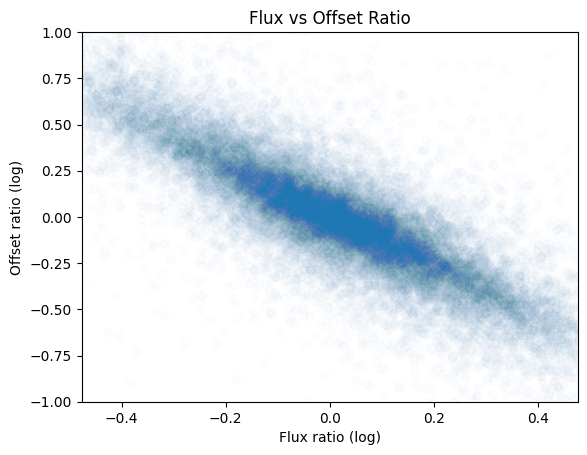

In [17]:
# plt.scatter(np.abs(np.log10(dps_df['flux_ratio'])), np.abs(np.log10(-dps_df['dv_l']/(dps_df['dv_r']))), alpha=.01)
plt.scatter((np.log10(dps_df['flux_ratio'])), (np.log10(-dps_df['dv_l']/(dps_df['dv_r']))), alpha=.01)
# plt.axvline(np.log10(1.3), color='k', linestyle='--', linewidth=1)
# plt.axhline(np.log10(2), color='k', linestyle='--', linewidth=1)
plt.ylim(bottom=-1, top=1)
plt.xlim(left=np.log10(1/3), right=np.log10(3))
plt.title('Flux vs Offset Ratio')
plt.xlabel('Flux ratio (log)')
plt.ylabel('Offset ratio (log)')
plt.savefig('./figures/Feb6/flux_offset_ratio.png')
plt.show()

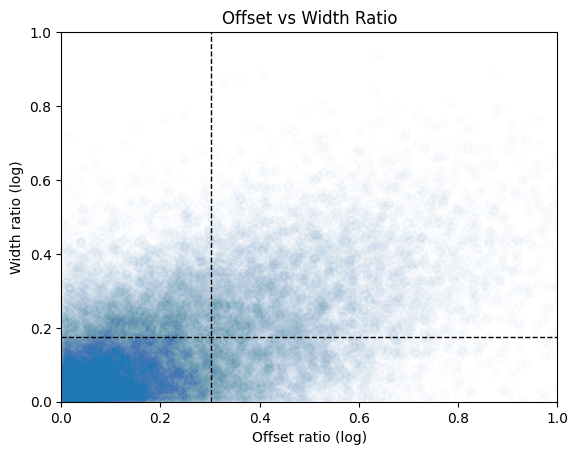

In [18]:
plt.scatter(np.abs(np.log10(-dps_df['dv_l']/(dps_df['dv_r']))), np.abs(np.log10(dps_df['width_ratio'])), alpha=0.01)
# plt.scatter((np.log10(-dps_df['dv_l']/(dps_df['dv_r']))), (np.log10(dps_df['width_ratio'])), alpha=0.01)
plt.axvline(np.log10(2), color='k', linestyle='--', linewidth=1)
plt.axhline(np.log10(1.5), color='k', linestyle='--', linewidth=1)
plt.xlim(left=0, right=1)
plt.ylim(bottom=0, top=1)
plt.title('Offset vs Width Ratio')
plt.xlabel('Offset ratio (log)')
plt.ylabel('Width ratio (log)')
plt.savefig('./figures/Feb6/offset_width_ratio_abs.png')
plt.show()

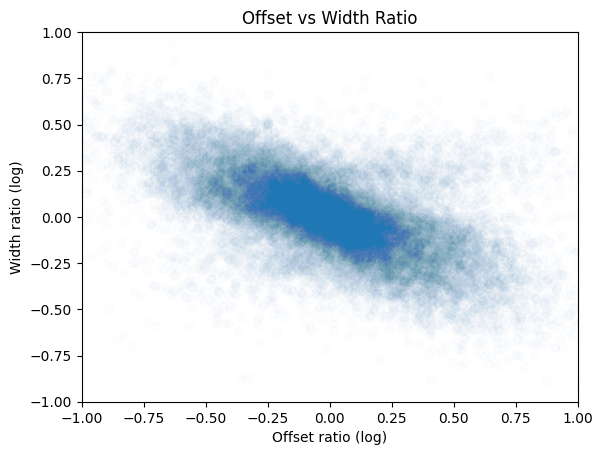

In [19]:
plt.scatter((np.log10(-dps_df['dv_l']/(dps_df['dv_r']))), (np.log10(dps_df['width_ratio'])), alpha=0.01)
plt.xlim(left=-1, right=1)
plt.ylim(bottom=-1, top=1)
plt.title('Offset vs Width Ratio')
plt.xlabel('Offset ratio (log)')
plt.ylabel('Width ratio (log)')
plt.show()

In [20]:
print(len(dps_df[np.log10(-dps_df['dv_l']/(dps_df['dv_r']))<0]))
print(len(dps_df[np.log10(-dps_df['dv_l']/(dps_df['dv_r']))>0]))

13203
12787


In [21]:
def extract_symmetry(df, flux=None, width=None, offset=None):
    combine_crit = np.ones(len(df), dtype=bool)
    
    if flux is True:
        # flux_crit = np.abs(np.log10(df['flux_ratio']))<np.log10(1.3)
        combine_crit &= np.abs(np.log10(df['flux_ratio']))<np.log10(1.3)
    elif flux is False:
        combine_crit &=  np.abs(np.log10(df['flux_ratio']))>=np.log10(1.3)
    elif flux is None:
        pass

    if width is True:
        combine_crit &= np.abs(np.log10(df['width_ratio']))<np.log10(1.5)
    elif width is False:
        combine_crit &= np.abs(np.log10(df['width_ratio']))>=np.log10(1.5)
    elif width is None:
        pass

    if offset is True:
        combine_crit &= np.abs(np.log10(-df['dv_l']/(df['dv_r'])))<np.log10(2)
    elif offset is False:
        combine_crit &= np.abs(np.log10(-df['dv_l']/(df['dv_r'])))>=np.log10(2)
    elif offset is None:
        pass

    return df[combine_crit]


In [22]:
classification_map = {
    1: 'SF', 4: 'COMP', 16: 'AGN', 64: 'LINER', 256: 'unclassified',
    2: 'double SF', 8: 'double COMP', 32: 'double AGN', 128: 'double LINER',
    5: 'SF+COMP', 17: 'SF+AGN', 65: 'SF+LINER',
    20: 'COMP+AGN', 68: 'COMP+LINER', 80: 'AGN+LINER',
    257: 'SF+uncertain', 260: 'COMP+uncertain', 272: 'AGN+uncertain', 320: 'LINER+uncertain',
    512: 'unclassified'
}

In [23]:
dps_df['BPT_class_str'] = dps_df['BPT_2comp'].map(classification_map)

In [24]:
sWsO = extract_symmetry(dps_df, flux=None, width=True, offset=True)
sWsO.head(5)

,TARGETID,RA,DEC,Z,LOGM,LOGSFR,dv_r,dv_l,sigma_r,sigma_l,...,dp_count,MORPHTYPE,SERSIC,SHAPE_R,VD_SL,incl,delta_dv,width_ratio,flux_ratio,BPT_class_str
0,39627739380056564,177.019318,-1.965308,0.323187,10.452706,0.941032,53.190807,-78.605568,50.497227,30.429680,...,2,REX,1.000000,1.275339,59.770000,0.000000,131.796371,0.713939,0.966651,unclassified
1,39627739380057506,177.058472,-1.984356,0.102379,10.324259,-0.880754,113.683365,-61.165852,41.490177,69.213905,...,1,REX,1.000000,0.781829,110.419998,0.000000,174.849213,1.445140,1.206655,unclassified
3,39627739380060210,177.177948,-1.988386,0.238389,10.496312,0.039087,73.980766,-94.167976,57.098171,51.152431,...,2,SER,2.648419,1.265829,124.010002,47.433067,168.148743,0.918791,0.842533,unclassified
4,39627739380061198,177.216431,-1.948593,0.103277,9.514435,0.903058,87.747307,-73.973824,38.576229,50.498489,...,5,SER,1.779606,0.794439,100.040001,50.672260,161.721130,1.187801,1.091301,SF+uncertain
5,39627739384252917,177.358017,-1.933391,0.082934,10.019835,-1.504955,55.170998,-69.174751,28.905651,50.764618,...,2,REX,1.000000,0.844727,73.330002,0.000000,124.345749,1.371994,0.618050,COMP+uncertain


In [25]:
print(sWsO['BPT_class_str'].value_counts())

BPT_class_str
unclassified      4901
double SF         3364
SF+uncertain      2401
SF+COMP            254
COMP+uncertain     170
AGN+uncertain      157
SF+AGN             119
double COMP        114
double AGN          79
COMP+AGN            69
COMP+LINER           3
AGN+LINER            1
SF+LINER             1
Name: count, dtype: int64


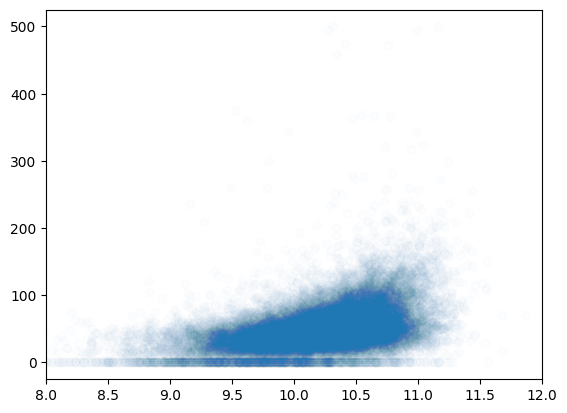

In [26]:
plt.scatter(dps_df['LOGM'], (dps_df['sigma_r']), alpha=0.01)
plt.xlim(left=8, right=12)
plt.show()

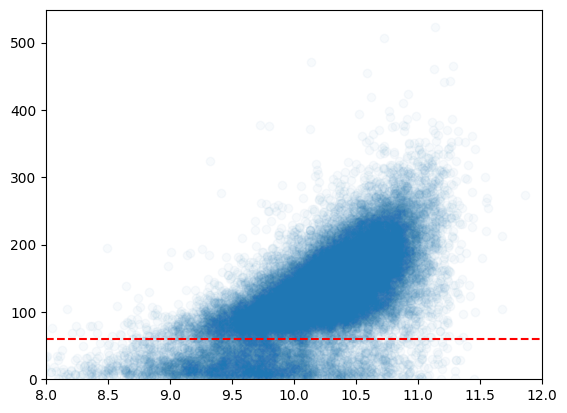

In [27]:
plt.scatter(dps_df['LOGM'], (dps_df['delta_dv']), alpha=0.03)
plt.axhline(60, color='r', linestyle='--')
plt.xlim(left=8, right=12)
plt.ylim(bottom=0)
plt.show()

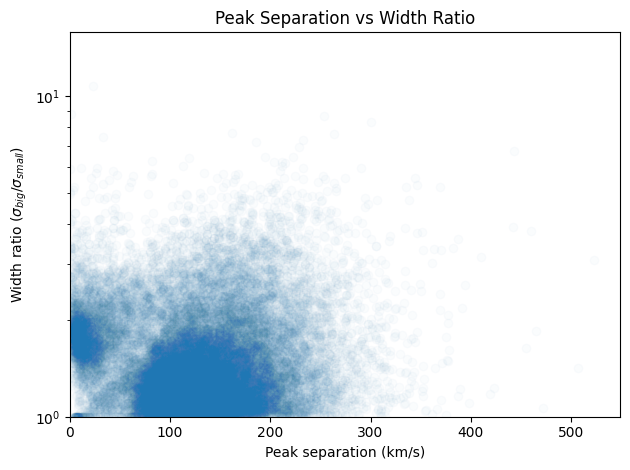

In [30]:
x = np.linspace(0, 500, 100)
y = 4e-5 * x**2 + 0.05

plt.scatter(dps_df['delta_dv'], 10**np.abs(np.log10(dps_df['width_ratio'])), alpha=0.02)
# plt.plot(x, y, color='r', linestyle='--')
# plt.axvline(60, color='r', linestyle='--')
# plt.axhline(0.1, color='r', linestyle='--')
plt.xlim(left=0)
plt.ylim(bottom=1, top=10**1.2)
plt.yscale('log')
plt.xlabel('Peak separation (km/s)')
plt.ylabel(r'Width ratio ($\sigma_{big}/\sigma_{small}$)')
plt.title('Peak Separation vs Width Ratio')
plt.tight_layout()
plt.savefig('./figures/Feb25/peak_sep_width_ratio.png')
plt.show()

In [33]:

# robust_dps = dps_df[(dps_df['BPT_class_str']!='unclassified')&(~dps_df['incl'].isnull())&(dps_df['dp_count']>1)&(dps_df['VD_SL']!=0)&(dps_df['LOGM']!=0)]
robust_dps = dps_df[(dps_df['BPT_class_str']!='unclassified')&(dps_df['VD_SL']!=0)&(dps_df['LOGM']!=0)]
robust_dps = robust_dps[(~robust_dps['width_ratio'].isnull())&(~robust_dps['flux_ratio'].isnull())]
robust_dps.sort_values(['width_ratio'], ascending=True).head(5)

,TARGETID,RA,DEC,Z,LOGM,LOGSFR,dv_r,dv_l,sigma_r,sigma_l,...,dp_count,MORPHTYPE,SERSIC,SHAPE_R,VD_SL,incl,delta_dv,width_ratio,flux_ratio,BPT_class_str
5825,39627758036322054,209.077072,-1.253912,0.247431,9.521063,1.103340,5.838779e-33,-1.362716,373.505615,30.938259,...,1,REX,1.000000,0.370823,376.290009,0.000000,1.362716,0.113711,2.648615,double SF
6729,39627763660882868,184.294128,-0.972807,0.188709,10.269643,-0.257766,1.586363e+02,-74.424500,495.164734,60.390194,...,1,DEV,4.000000,0.977100,150.339996,35.666496,233.060806,0.136583,0.976677,AGN+uncertain
15279,39627788193369968,206.683517,0.062199,0.356616,10.804720,0.203521,6.843856e+00,-40.181339,150.486435,0.010000,...,1,EXP,1.000000,0.739220,207.690002,47.189030,47.025196,0.176157,0.190874,AGN+uncertain
17519,39627794396741730,216.252991,0.233792,0.322136,11.051679,1.321636,2.198707e+01,-125.071960,158.526367,8.678017,...,1,SER,3.216498,2.833057,102.769997,21.524508,147.059036,0.179990,1.097063,AGN+uncertain
22340,39627812264477753,201.302582,1.052723,0.304811,10.965445,1.524045,5.376753e+01,-150.908188,195.648865,23.860506,...,1,SER,1.457420,1.032252,367.070007,55.000683,204.675720,0.186131,0.798170,AGN+uncertain


In [34]:
print(len(robust_dps))

12835


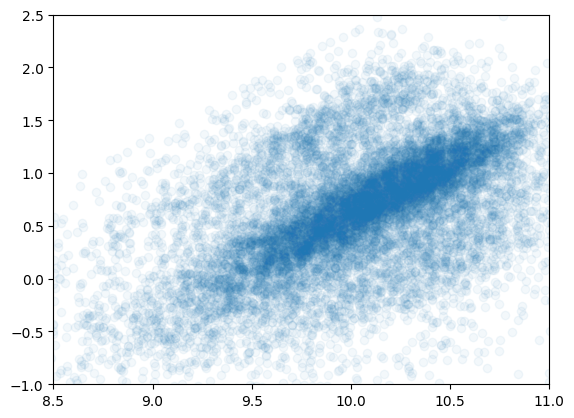

In [35]:
x = np.linspace(8, 12, 100)
y = -9 + 0.9 * x

plt.scatter(robust_dps['LOGM'], robust_dps['LOGSFR'], alpha=0.05)
plt.ylim((-1, 2.5))
plt.xlim((8.5, 11))
# plt.plot(x, y+0.6, color='r', linestyle='--', label='MS: LOGSFR = -9 + 0.9 * LOGM')
# plt.plot(x, y+0.9, color='r', linestyle=':')
# plt.plot(x, y+0.3, color='r', linestyle=':')
# plt.plot(x, y+1.2, color='gray', linestyle='--')
# plt.legend()
plt.show()

In [36]:
logm_bin_bound = np.linspace(8.5, 11, 7, endpoint=True)
logsfr_bin_bound = np.linspace(-1, 2.5, 7, endpoint=True)

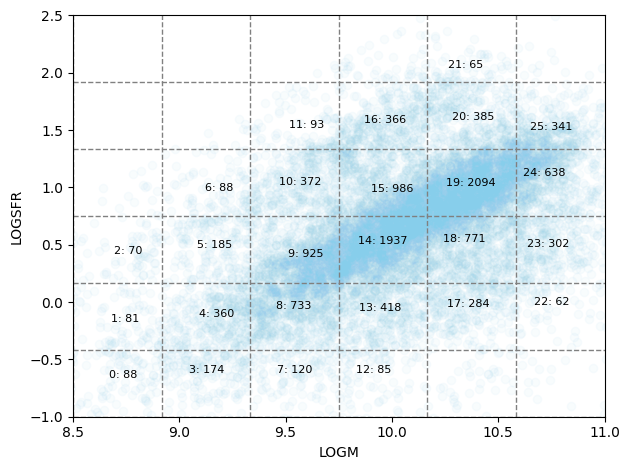

In [145]:

plt.scatter(robust_dps['LOGM'], robust_dps['LOGSFR'], alpha=0.05, color='skyblue')
for i in range(len(logm_bin_bound)-1):
    plt.axvline(logm_bin_bound[i], color='gray', linestyle='--', linewidth=1)
for j in range(len(logsfr_bin_bound)-1):
    plt.axhline(logsfr_bin_bound[j], color='gray', linestyle='--', linewidth=1)

bin_num = 0
bin_dps_list = []
for i in range(len(logm_bin_bound)-1):
    for j in range(len(logsfr_bin_bound)-1):
        bin_dps = robust_dps[(robust_dps['LOGM']>=logm_bin_bound[i]) & (robust_dps['LOGM']<logm_bin_bound[i+1]) & (robust_dps['LOGSFR']>=logsfr_bin_bound[j]) & (robust_dps['LOGSFR']<logsfr_bin_bound[j+1])]
        # print(f'Bin LOGM: [{logm_bin_bound[i]:.2f}, {logm_bin_bound[i+1]:.2f}), LOGSFR: [{logsfr_bin_bound[j]:.2f}, {logsfr_bin_bound[j+1]:.2f}), Count: {len(bin_dps)}')
        # plt.scatter(bin_dps['LOGM'], bin_dps['LOGSFR'], alpha=0.1, color='skyblue')
        if len(bin_dps)>50:
            bin_dps_list.append(bin_dps)
            plt.text(bin_dps['LOGM'].mean(), bin_dps['LOGSFR'].mean(), f'{bin_num}: {len(bin_dps)}', fontsize=8, ha='center')
            bin_num += 1

plt.ylim((-1, 2.5))
plt.xlim((8.5, 11))
plt.xlabel('LOGM')
plt.ylabel('LOGSFR')
plt.tight_layout()
plt.savefig('./figures/Feb25/logm_logsfr_bins.png')
plt.show()

In [39]:
logm_group = [[0, 1, 2, 3], [4, 5, 6, 7, 8], [9, 10, 11, 12, 13], [14, 15, 16, 17, 18], [19, 20, 21]]
logm_bin = [9, 9.5, 10, 10.5, 11]

logsfr_group = [[0, 4, 9], [1, 5, 10, 14], [2, 6, 11, 15, 19], [3, 7, 12, 16, 20], [8, 13, 17, 21], [18]]
logsfr_bin = [-0.5, 0.0, 0.5, 1.0, 1.5, 2]

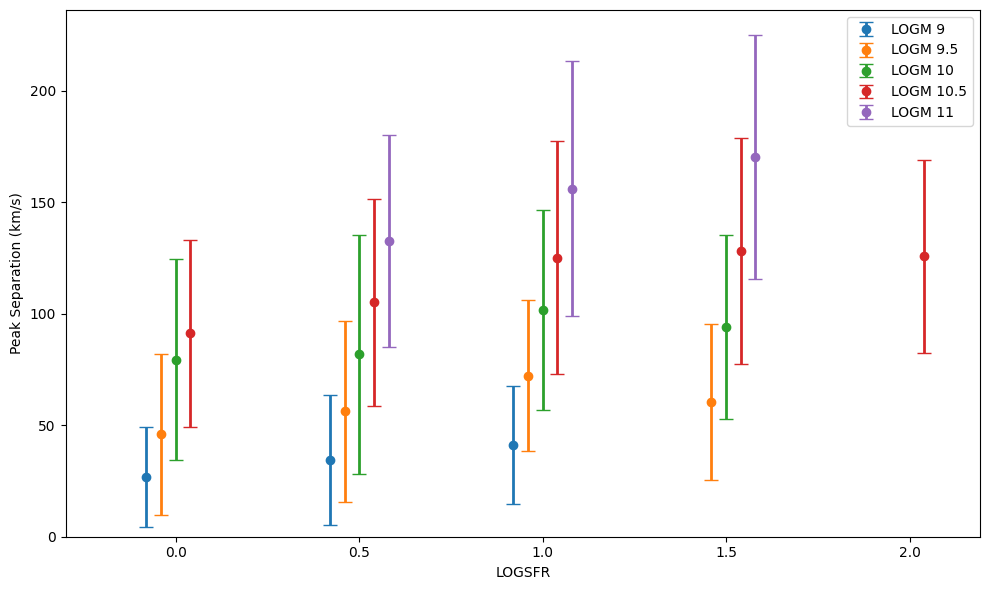

In [40]:
colors = ['C0', 'C1', 'C2', 'C3', 'C4']
offsets = np.arange(-0.08, 0.12, 0.04)
plt.figure(figsize=(10, 6))
for i, subgroup in enumerate(logm_group):
    plt.errorbar(-1, -1, yerr=0, color=colors[i], fmt='o', capsize=5, ecolor=colors[i], elinewidth=2, label=f'LOGM {logm_bin[i]}')
    # plt.scatter(-1, -1, color=colors[i], label=f'LOGM {logm_bin[i]}')
    for bin_idx in subgroup:
        bin_dps = bin_dps_list[bin_idx]
        for j in range(len(logsfr_group)):
            if bin_idx in logsfr_group[j]:
                # plt.scatter(logsfr_bin[j], bin_dps['delta_dv'].mean(), color=colors[i])
                plt.errorbar(logsfr_bin[j] + offsets[i], bin_dps['delta_dv'].mean(), yerr=bin_dps['delta_dv'].std(), color=colors[i], fmt='o', capsize=5, ecolor=colors[i], elinewidth=2)
plt.ylim(bottom=0)
plt.xlim(left=-0.3)
plt.xlabel('LOGSFR')
plt.ylabel('Peak Separation (km/s)')
plt.legend()
plt.tight_layout()
plt.savefig('./figures/Feb25/logm_sep.png')
plt.show()

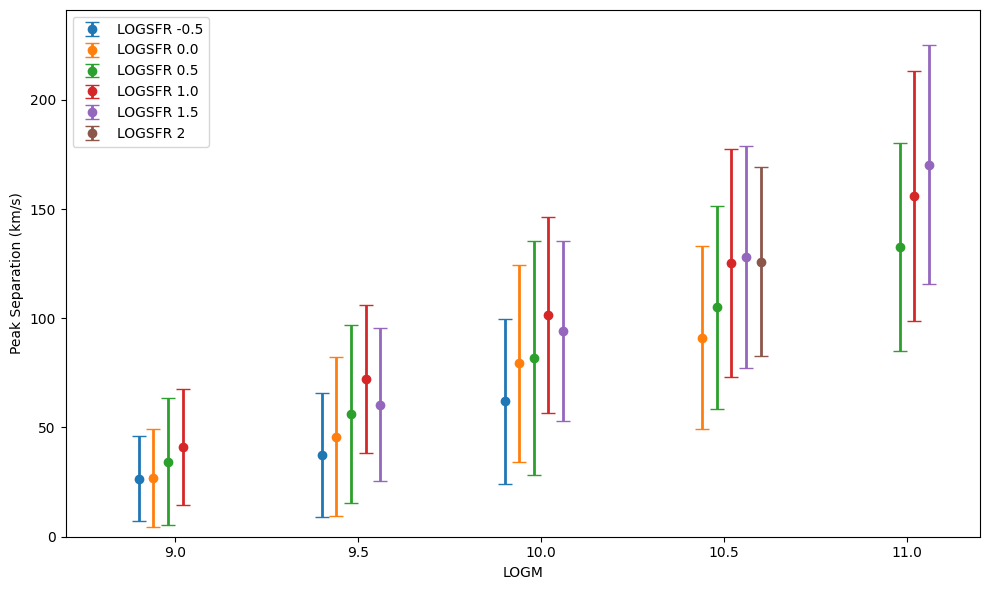

In [42]:
colors = ['C0', 'C1', 'C2', 'C3', 'C4', 'C5']
offsets = np.arange(-0.1, 0.11, 0.04)
plt.figure(figsize=(10, 6))
for i, subgroup in enumerate(logsfr_group):
    plt.errorbar(0, -100, yerr=0, color=colors[i], fmt='o', capsize=5, ecolor=colors[i], elinewidth=2, label=f'LOGSFR {logsfr_bin[i]}')
    for bin_idx in subgroup:
        bin_dps = bin_dps_list[bin_idx]
        for j in range(len(logm_group)):
            if bin_idx in logm_group[j]:
                # plt.scatter(logm_bin[j], bin_dps['delta_dv'].mean(), color=colors[i], s=50)
                plt.errorbar(logm_bin[j] + offsets[i], bin_dps['delta_dv'].mean(), yerr=bin_dps['delta_dv'].std(), color=colors[i], fmt='o', capsize=5, ecolor=colors[i], elinewidth=2)

# x = np.linspace(9, 11, 100)
# y = 55*(x-9)+55
# plt.plot(x, y, color='black', lw=2)
plt.xlabel('LOGM')
plt.ylabel('Peak Separation (km/s)')
plt.xlim(left=8.7, right=11.2)
plt.ylim(bottom=0)
plt.legend()
plt.tight_layout()
plt.savefig('./figures/Feb25/logsfr_sep.png')
plt.show()

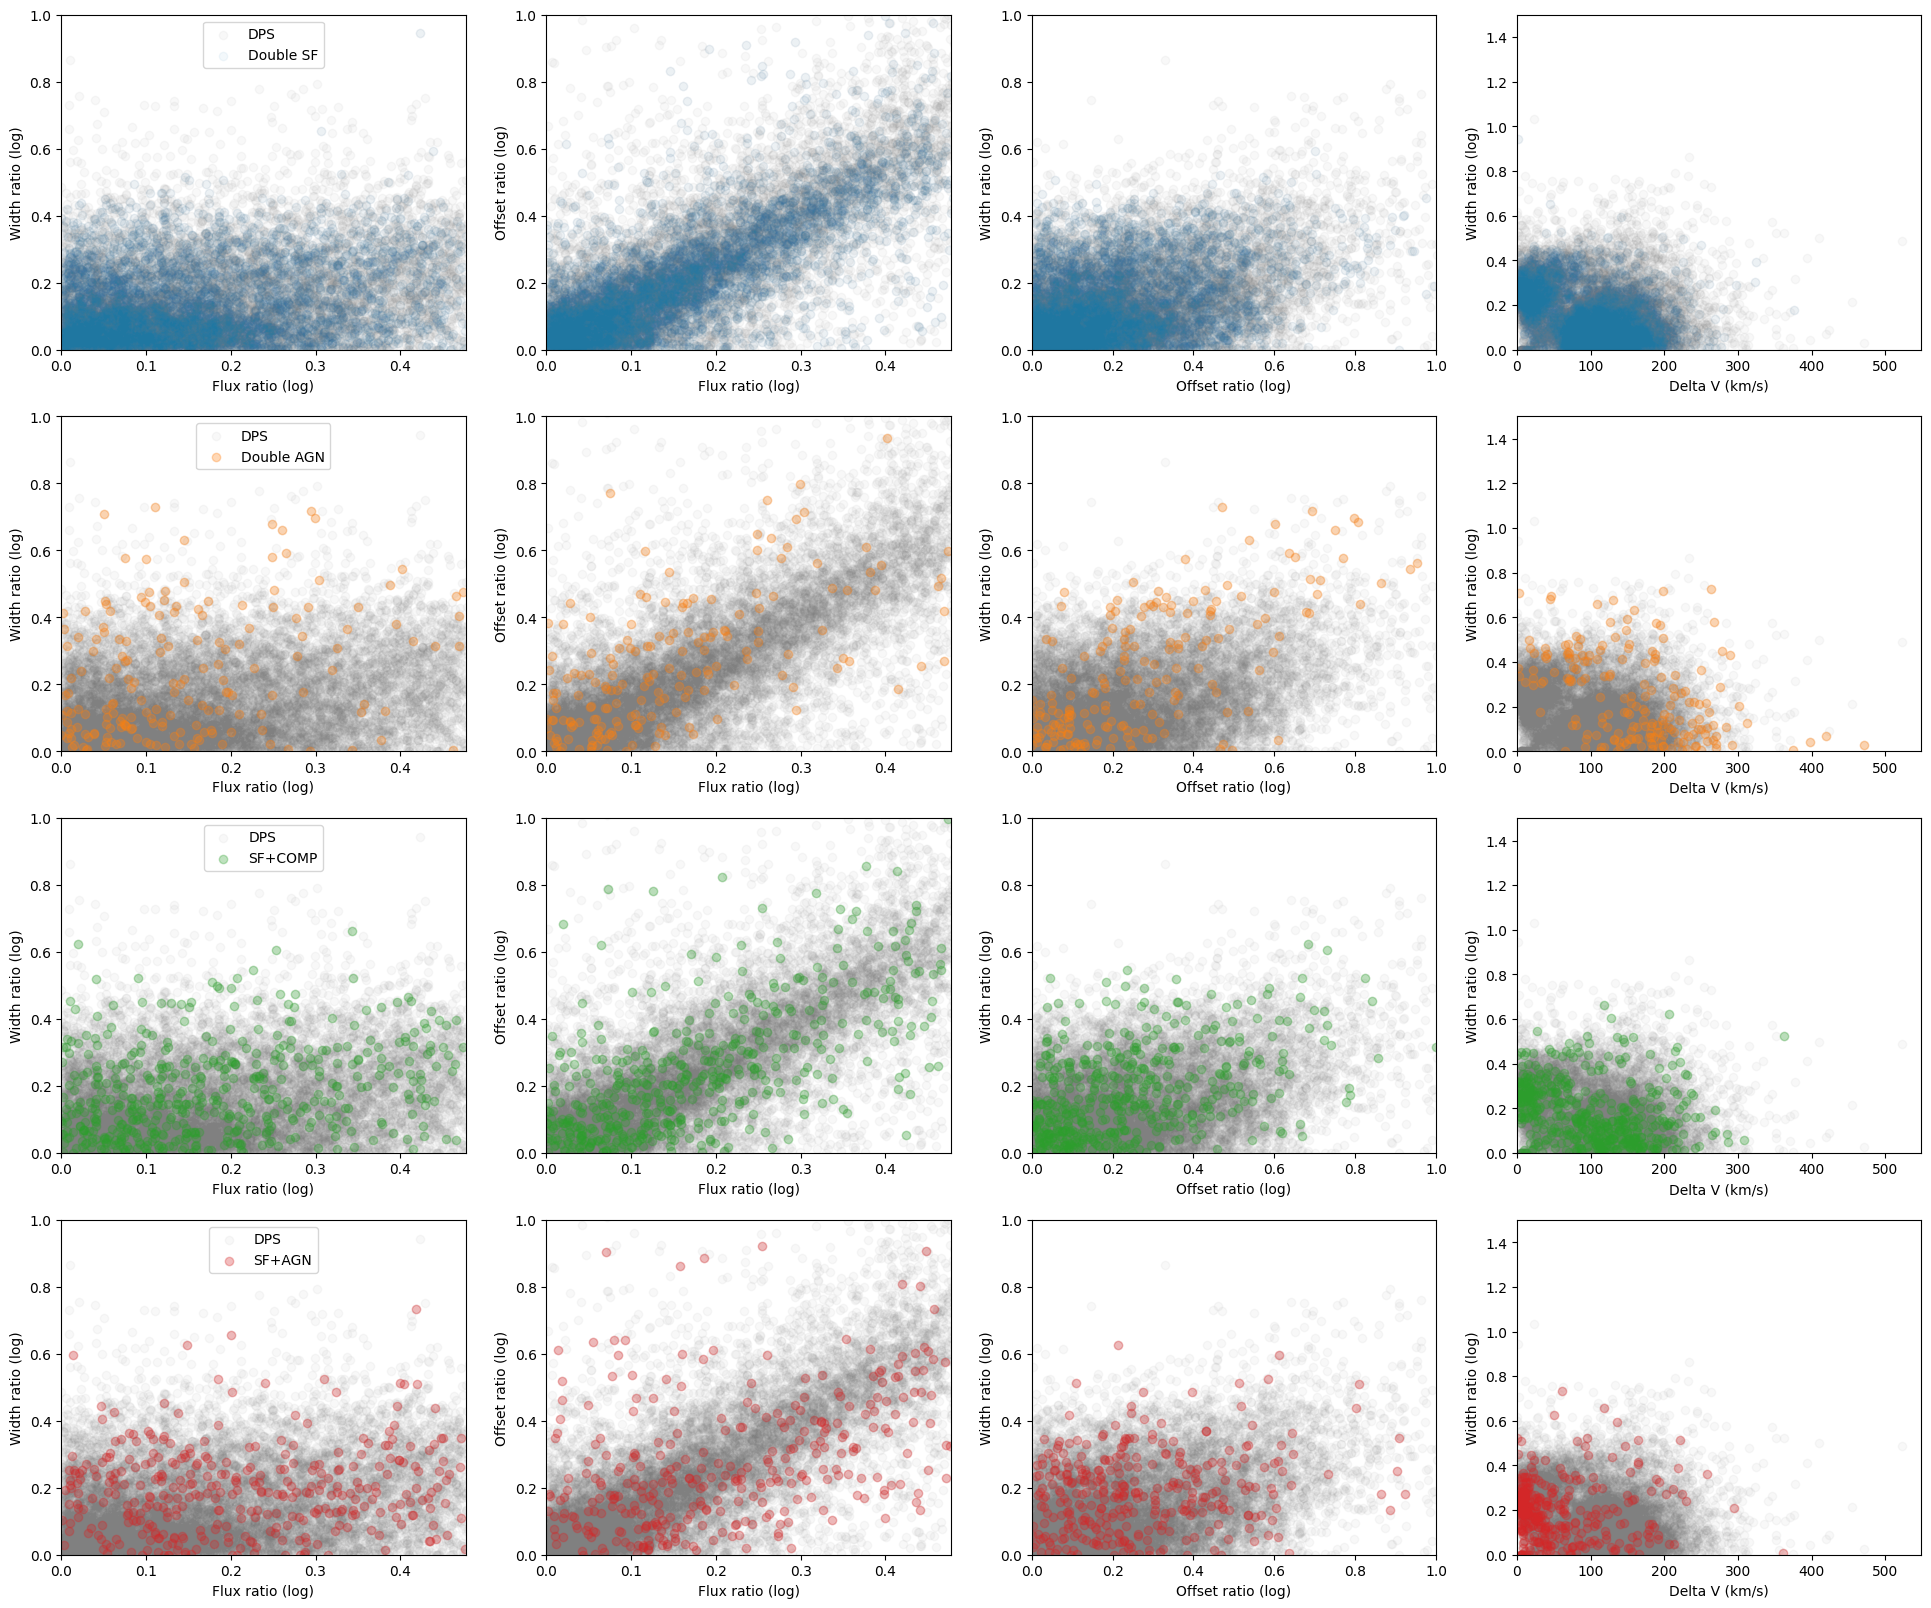

In [44]:

dSF = robust_dps[robust_dps['BPT_class_str']=='double SF'].copy()
dAGN = robust_dps[robust_dps['BPT_class_str']=='double AGN'].copy()
SF_COMP = robust_dps[robust_dps['BPT_class_str']=='SF+COMP'].copy()
SF_AGN = robust_dps[robust_dps['BPT_class_str']=='SF+AGN'].copy()

fig, axes = plt.subplots(4, 4, figsize=(24, 20))

labels = ['Double SF', 'Double AGN', 'SF+COMP', 'SF+AGN']
colors = ['C0', 'C1', 'C2', 'C3']
for i, subset in enumerate([dSF, dAGN, SF_COMP, SF_AGN]):
    ax = axes[i]
    ax[0].scatter(np.abs(np.log10(robust_dps['flux_ratio'])), np.abs(np.log10(robust_dps['width_ratio'])), alpha=.05, color='gray', label='DPS')
    ax[0].scatter(np.abs(np.log10(subset['flux_ratio'])), np.abs(np.log10(subset['width_ratio'])), alpha=.3 if i!=0 else 0.05, color=colors[i], label=labels[i])
    ax[0].set_xlim(left=0, right=np.log10(3))
    ax[0].set_ylim(bottom=0, top=np.log10(10))
    ax[0].set_xlabel('Flux ratio (log)')
    ax[0].set_ylabel('Width ratio (log)')
    ax[0].legend()


    ax[1].scatter(np.abs(np.log10(robust_dps['flux_ratio'])), np.abs(np.log10(-robust_dps['dv_l']/(robust_dps['dv_r']))), alpha=.05, color='gray', label='DPS')
    ax[1].scatter(np.abs(np.log10(subset['flux_ratio'])), np.abs(np.log10(-subset['dv_l']/(subset['dv_r']))), alpha=.3 if i!=0 else 0.05, color=colors[i], label=labels[i])
    ax[1].set_ylim(bottom=0, top=1)
    ax[1].set_xlim(left=0, right=np.log10(3))
    ax[1].set_xlabel('Flux ratio (log)')
    ax[1].set_ylabel('Offset ratio (log)')

    ax[2].scatter(np.abs(np.log10(-robust_dps['dv_l']/(robust_dps['dv_r']))), np.abs(np.log10(robust_dps['width_ratio'])), alpha=0.05, color='gray', label='DPS')
    ax[2].scatter(np.abs(np.log10(-subset['dv_l']/(subset['dv_r']))), np.abs(np.log10(subset['width_ratio'])), alpha=0.3 if i!=0 else 0.05, color=colors[i], label=labels[i])
    ax[2].set_xlim(left=0, right=1)
    ax[2].set_ylim(bottom=0, top=1)
    ax[2].set_xlabel('Offset ratio (log)')
    ax[2].set_ylabel('Width ratio (log)')
    
    ax[3].scatter(robust_dps['delta_dv'], np.abs(np.log10(robust_dps['width_ratio'])), alpha=0.05, color='gray', label='DPS')
    ax[3].scatter(subset['delta_dv'], np.abs(np.log10(subset['width_ratio'])), alpha=0.3 if i!=0 else 0.05, color=colors[i], label=labels[i])
    ax[3].set_xlim(left=0)
    ax[3].set_ylim(bottom=0, top=1.5)
    ax[3].set_xlabel('Delta V (km/s)')
    ax[3].set_ylabel('Width ratio (log)')


plt.show()




In [45]:
merger_cand = robust_dps[((robust_dps['width_ratio']<1/3)|(robust_dps['width_ratio']>3))].copy()
merger_cand_b = merger_cand[(merger_cand['width_ratio']>3)&(merger_cand['sigma_l']<250)&(merger_cand['sigma_r']>1)].copy()
merger_cand_r = merger_cand[(merger_cand['width_ratio']<1/3)&(merger_cand['sigma_r']<250)&(merger_cand['sigma_l']>1)].copy()
merger_cand = pd.concat([merger_cand_b, merger_cand_r])
merger_cand.sort_values(['width_ratio'], ascending=False).head(5)

,TARGETID,RA,DEC,Z,LOGM,LOGSFR,dv_r,dv_l,sigma_r,sigma_l,...,dp_count,MORPHTYPE,SERSIC,SHAPE_R,VD_SL,incl,delta_dv,width_ratio,flux_ratio,BPT_class_str
25147,39627823970780277,179.054306,1.431388,0.332877,10.820004,1.507084,1.899154e+02,-24.734459,11.509928,182.372482,...,1,SER,0.797546,1.127784,114.199997,51.671078,214.649872,6.203477,2.004067,AGN+uncertain
24236,39627818316858830,202.075577,1.366346,0.079271,9.774653,-0.263470,8.060292e-10,-11.523681,14.042250,216.877533,...,1,REX,1.000000,1.926894,17.260000,0.000000,11.523681,5.989530,0.518630,SF+uncertain
24426,39627818392356897,206.583344,1.331737,0.315747,10.412442,0.004569,1.205123e+02,-13.156987,27.130077,222.601425,...,3,REX,1.000000,0.444960,43.939999,0.000000,133.669250,5.778536,1.866796,AGN+uncertain
20955,39627806430204923,213.743362,0.855273,0.318180,10.465372,1.259652,1.465246e+02,-18.083618,16.211191,174.945343,...,1,REX,1.000000,0.369185,149.440002,0.000000,164.608261,5.516503,1.356617,AGN+uncertain
19682,39627805851389902,179.199615,0.843170,0.235508,10.467430,1.479001,1.293736e+02,-26.106329,13.081863,170.639618,...,1,SER,1.100929,1.478815,117.050003,37.498905,155.479904,5.355939,1.359014,AGN+uncertain


In [46]:
# for i, id in enumerate(merger_cand.sort_values(['width_ratio'], ascending=False).head(10)['TARGETID'].to_list()):
#     df = merger_cand[merger_cand['TARGETID'] == id]
#     print(df['BPT_class_str'])
#     print(image_link(df['RA'].iloc[0], df['DEC'].iloc[0], plot=True, save_image=True, fname=f"./images/{id}_image.jpg"))

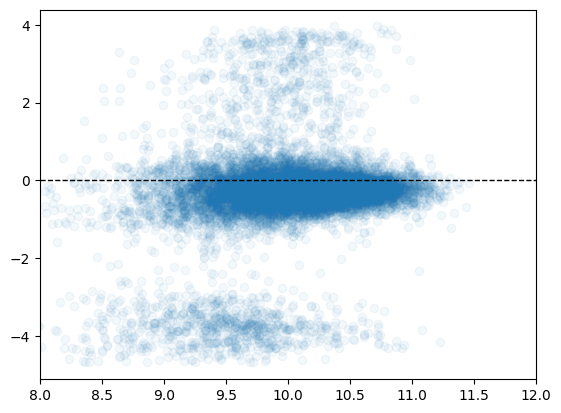

In [47]:
plt.scatter(robust_dps['LOGM'], np.log10(robust_dps['sigma_l']/robust_dps['VD_SL']), alpha=0.05)
plt.axhline(0, color='k', linestyle='--', linewidth=1)
plt.xlim(left=8, right=12)
plt.show()

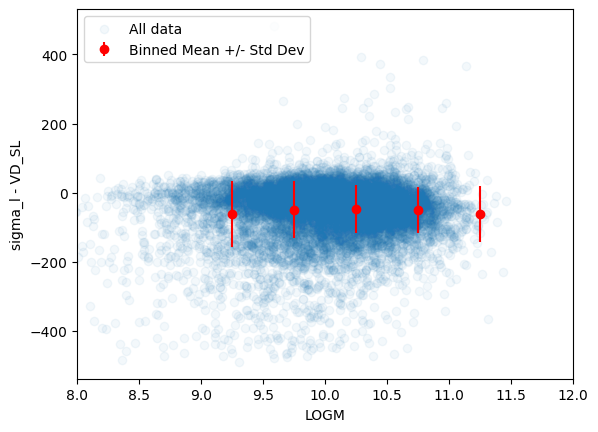

In [48]:
from scipy.stats import binned_statistic

# Bin the data by 'LOGM'
bin_means, bin_edges, binnumber = binned_statistic(robust_dps['LOGM'],
                                                   robust_dps['sigma_l'] - robust_dps['VD_SL'],
                                                   statistic='mean',
                                                   bins=5, range=(9, 11.5))
bin_stds, _, _ = binned_statistic(robust_dps['LOGM'],
                                  robust_dps['sigma_l'] - robust_dps['VD_SL'],
                                  statistic='std',
                                  bins=5, range=(9, 11.5))
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

# Create the plot
# plt.figure(figsize=(8, 6))
# Plot the original scatter data
plt.scatter(robust_dps['LOGM'], robust_dps['sigma_l'] - robust_dps['VD_SL'], alpha=0.05, label='All data')
# Plot the binned means with error bars
plt.errorbar(bin_centers, bin_means, yerr=bin_stds, fmt='o', color='r', label='Binned Mean +/- Std Dev')

# Set plot labels and limits
plt.xlabel('LOGM')
plt.ylabel('sigma_l - VD_SL')
plt.xlim(left=8, right=12)
plt.legend()
plt.show()

In [49]:
robust_dps.columns

Index(['TARGETID', 'RA', 'DEC', 'Z', 'LOGM', 'LOGSFR', 'dv_r', 'dv_l',
       'sigma_r', 'sigma_l', 'sigma_1comp', 'p_value', 'OII3726_dp',
       'OII3729_dp', 'Hbeta_dp', 'OIII4959_dp', 'OIII5007_dp', 'NII6548_dp',
       'NII6583_dp', 'Halpha_dp', 'SII6716_dp', 'SII6731_dp', 'OII3726_rank',
       'OII3729_rank', 'Hbeta_rank', 'OIII4959_rank', 'OIII5007_rank',
       'NII6548_rank', 'NII6583_rank', 'Halpha_rank', 'SII6716_rank',
       'SII6731_rank', 'BPT_1comp', 'BPT_2comp', 'dp_count', 'MORPHTYPE',
       'SERSIC', 'SHAPE_R', 'VD_SL', 'incl', 'delta_dv', 'width_ratio',
       'flux_ratio', 'BPT_class_str'],
      dtype='object')

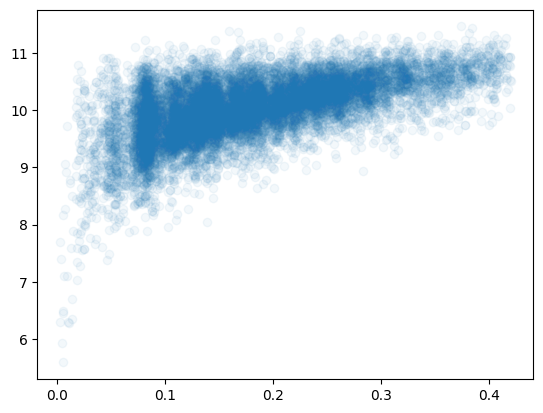

In [51]:
plt.scatter(robust_dps['Z'], robust_dps['LOGM'], alpha=0.05)
plt.show()

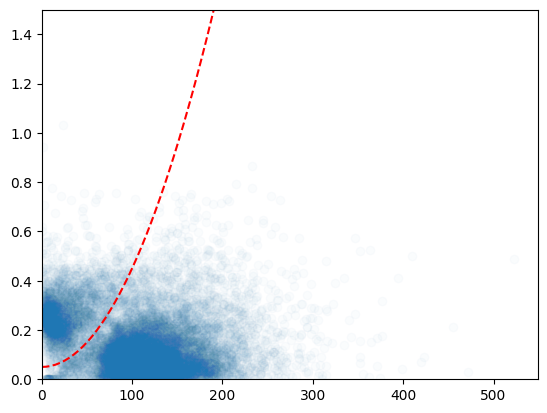

In [98]:
x = np.linspace(0, 500, 100)
y = 4e-5 * x**2 + 0.05

plt.scatter(robust_dps['delta_dv'], np.abs(np.log10(robust_dps['width_ratio'])), alpha=0.02)
plt.plot(x, y, color='r', linestyle='--')
plt.xlim(left=0)
plt.ylim(bottom=0, top=1.5)
plt.show()

In [99]:
cake_dps = robust_dps[4e-5 * robust_dps['delta_dv']**2 + 0.05 < np.abs(np.log10(robust_dps['width_ratio']))].copy()
horn_dps = robust_dps[4e-5 * robust_dps['delta_dv']**2 + 0.05 > np.abs(np.log10(robust_dps['width_ratio']))].copy()

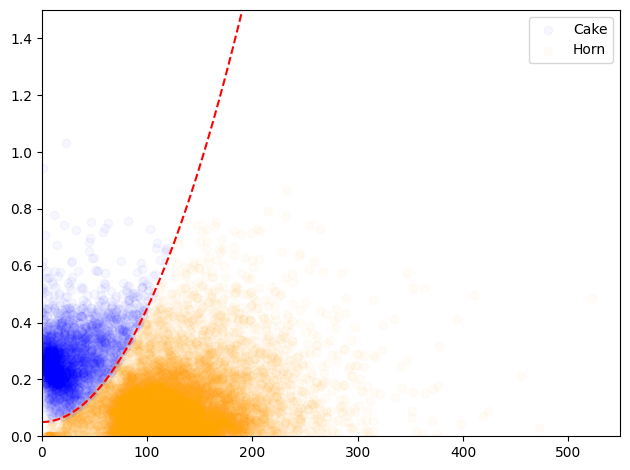

In [100]:
plt.scatter(cake_dps['delta_dv'], np.abs(np.log10(cake_dps['width_ratio'])), alpha=0.03, color='blue', label='Cake')
plt.scatter(horn_dps['delta_dv'], np.abs(np.log10(horn_dps['width_ratio'])), alpha=0.03, color='orange', label='Horn')
plt.plot(x, y, color='r', linestyle='--')
plt.xlim(left=0)
plt.ylim(bottom=0, top=1.5)
plt.legend()
plt.tight_layout()
plt.savefig('./figures/Feb25/cake_horn.png')
plt.show()

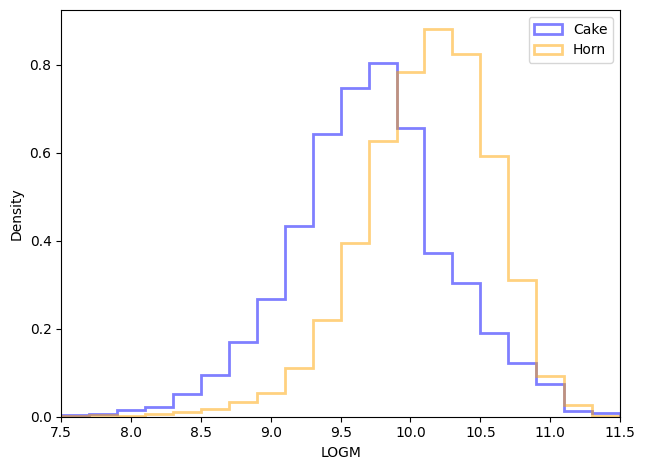

In [101]:
plt.hist(cake_dps['LOGM'], bins=20, alpha=0.5, label='Cake', density=True, histtype='step', linewidth=2, color='blue', range=(7.5, 11.5))
plt.hist(horn_dps['LOGM'], bins=20, alpha=0.5, label='Horn', density=True, histtype='step', linewidth=2, color='orange', range=(7.5, 11.5))
plt.xlabel('LOGM')
plt.ylabel('Density')
plt.legend()
plt.tight_layout()
plt.xlim(left=7.5, right=11.5)
plt.savefig('./figures/Feb25/cake_horn_logm.png')
plt.show()

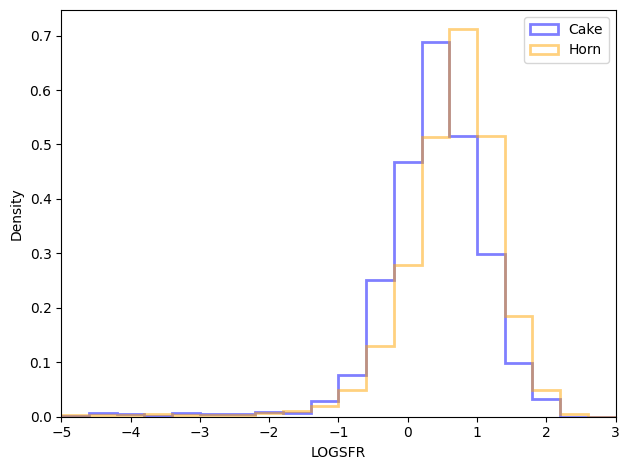

In [102]:
plt.hist(cake_dps['LOGSFR'], bins=20, alpha=0.5, label='Cake', density=True, histtype='step', linewidth=2, color='blue', range=(-5, 3))
plt.hist(horn_dps['LOGSFR'], bins=20, alpha=0.5, label='Horn', density=True, histtype='step', linewidth=2, color='orange', range=(-5, 3))
plt.xlabel('LOGSFR')
plt.ylabel('Density')
plt.legend()
plt.tight_layout()
plt.xlim(left=-5, right=3)
plt.tight_layout()
plt.savefig('./figures/Feb25/cake_horn_logsfr.png')
plt.show()

In [103]:
print(cake_dps['BPT_class_str'].value_counts(normalize=True)*100)
print(len(cake_dps))

BPT_class_str
double SF          40.195394
SF+uncertain       34.368458
SF+AGN              6.908583
SF+COMP             5.861828
COMP+uncertain      5.198883
AGN+uncertain       4.396371
double AGN          1.360782
double COMP         0.907188
COMP+AGN            0.697837
SF+LINER            0.034892
AGN+LINER           0.034892
LINER+uncertain     0.034892
Name: proportion, dtype: float64
2866


In [104]:
print(horn_dps['BPT_class_str'].value_counts(normalize=True)*100)
print(len(horn_dps))

BPT_class_str
SF+uncertain       42.391413
double SF          40.535661
AGN+uncertain       4.092687
COMP+uncertain      3.851941
SF+COMP             3.450697
SF+AGN              1.504664
double AGN          1.484602
double COMP         1.464540
COMP+AGN            1.113452
LINER+uncertain     0.040124
COMP+LINER          0.040124
AGN+LINER           0.020062
SF+LINER            0.010031
Name: proportion, dtype: float64
9969


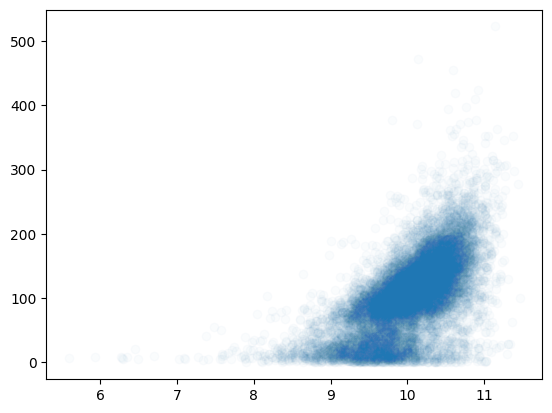

In [105]:
plt.scatter(robust_dps['LOGM'], robust_dps['delta_dv'], alpha=0.02)
# x = np.linspace(8, 11.5, 100)
# y = 55*(x-9)+55
# plt.plot(x, y, color='black', lw=2)
plt.show()

In [106]:
len(merger_cand)

178

In [107]:
merger_cand.sort_values(by='SHAPE_R', ascending=True).head(30)

,TARGETID,RA,DEC,Z,LOGM,LOGSFR,dv_r,dv_l,sigma_r,sigma_l,...,dp_count,MORPHTYPE,SERSIC,SHAPE_R,VD_SL,incl,delta_dv,width_ratio,flux_ratio,BPT_class_str
12770,39627781868359233,189.667679,-0.128895,0.204595,9.150351,1.288560,3.605014e+01,-20.082800,52.315506,187.699219,...,10,REX,1.000000,0.252451,462.040009,0.000000,56.132942,3.144204,1.175733e+00,double COMP
12392,39627781725753388,181.210297,-0.199903,0.119530,9.546997,0.146538,4.166625e+00,-12.662980,39.003746,156.730759,...,10,REX,1.000000,0.306086,72.820000,0.000000,16.829605,3.148004,4.090945e-01,double AGN
10332,39627775648208586,178.990906,-0.403864,0.250296,10.410080,-0.460224,1.907821e+01,-120.866035,113.949242,17.914026,...,2,REX,1.000000,0.363201,86.470001,0.000000,139.944244,0.291361,4.496470e-01,SF+uncertain
20955,39627806430204923,213.743362,0.855273,0.318180,10.465372,1.259652,1.465246e+02,-18.083618,16.211191,174.945343,...,1,REX,1.000000,0.369185,149.440002,0.000000,164.608261,5.516503,1.356617e+00,AGN+uncertain
8684,39627769738430225,186.589813,-0.781932,0.284080,10.399223,1.589749,1.180609e+02,-17.696684,25.473671,123.629662,...,3,REX,1.000000,0.375545,146.039993,0.000000,135.757553,3.321926,1.612438e+00,SF+COMP
5838,39627758040519923,209.470810,-1.319891,0.409494,10.987538,2.041643,1.081574e+02,-20.078100,37.206657,181.103363,...,1,REX,1.000000,0.392231,82.769997,0.000000,128.235458,4.034580,1.794181e+00,SF+COMP
18824,39627800235214582,204.327087,0.621960,0.276975,10.449203,1.105227,5.672235e+01,-86.754570,130.683807,29.761448,...,4,REX,1.000000,0.400948,176.509995,0.000000,143.476913,0.308590,1.506428e+00,SF+COMP
6667,39627763639911175,183.029068,-1.072288,0.113915,9.275297,1.141646,6.485963e+01,-40.023403,208.526596,59.595619,...,9,REX,1.000000,0.438636,124.989998,0.000000,104.883026,0.322254,1.415944e+00,double COMP
24426,39627818392356897,206.583344,1.331737,0.315747,10.412442,0.004569,1.205123e+02,-13.156987,27.130077,222.601425,...,3,REX,1.000000,0.444960,43.939999,0.000000,133.669250,5.778536,1.866796e+00,AGN+uncertain
15912,39627788457611299,222.424561,0.001545,0.112255,9.284292,1.317066,8.595424e+00,-50.544670,42.070316,182.314743,...,1,SER,5.140268,0.477854,138.279999,23.785040,59.140095,3.470759,3.691488e-01,double COMP


In [109]:
print(merger_cand['MORPHTYPE'].value_counts(normalize=True))

MORPHTYPE
SER    0.662921
REX    0.162921
DEV    0.117978
EXP    0.056180
Name: proportion, dtype: float64


In [113]:
merger_cand.sort_values(by='SERSIC', ascending=True).head(20)

,TARGETID,RA,DEC,Z,LOGM,LOGSFR,dv_r,dv_l,sigma_r,sigma_l,...,dp_count,MORPHTYPE,SERSIC,SHAPE_R,VD_SL,incl,delta_dv,width_ratio,flux_ratio,BPT_class_str
749,39627740042759487,216.649796,-1.998467,0.275597,10.619296,1.140777,6.071157e+00,-2.806637e+01,158.791992,30.949692,...,2,SER,0.500000,1.797086,83.599998,66.339720,3.413752e+01,0.261341,0.523581,COMP+uncertain
2889,39627751518374018,180.610947,-1.487653,0.150886,10.660643,-8.282505,1.924204e+01,-9.047920e+01,184.979843,22.922718,...,1,SER,0.500000,3.760101,472.760010,61.494495,1.097212e+02,0.208625,0.453930,AGN+uncertain
20307,39627806132409690,195.980347,0.649483,0.371827,10.268726,1.929244,3.098246e+01,-1.892368e+01,176.623322,32.574051,...,3,SER,0.500000,1.141954,187.059998,53.776978,4.990614e+01,0.235557,1.406165,SF+AGN
3424,39627751757448774,194.821686,-1.573625,0.168504,10.665784,1.110838,6.071265e+01,-3.229084e+01,171.268936,47.474007,...,5,SER,0.535460,5.108536,154.229996,62.444730,9.300349e+01,0.326508,1.591683,SF+AGN
21900,39627812037988321,187.943954,0.981470,0.146044,10.290135,1.085277,1.172983e+02,-2.040418e+01,17.977085,106.842506,...,4,SER,0.567813,2.227698,109.349998,77.917490,1.377025e+02,3.046524,2.638705,SF+uncertain
24094,39627818258140974,198.685837,1.363228,0.387003,10.232123,1.754935,1.964230e+01,-7.545430e+01,105.034401,18.720751,...,4,SER,0.585539,1.178145,173.759995,56.940475,9.509660e+01,0.298424,0.653341,SF+AGN
9810,39627770195609133,213.817230,-0.687208,0.289668,10.538917,1.497841,4.264589e+01,-2.698658e+00,18.091917,148.479797,...,2,SER,0.595702,1.254058,146.250000,47.692234,4.534455e+01,4.497045,2.023785,double SF
8631,39627769717458009,185.297592,-0.786711,0.209338,10.576923,1.014431,1.948908e+02,-1.571261e+02,34.660259,149.947693,...,2,SER,0.614774,1.670016,397.320007,62.618950,3.520168e+02,3.326816,0.553915,SF+uncertain
16451,39627793914401399,187.744080,0.175818,0.308183,9.544332,1.400752,3.568757e+01,-1.466460e+02,47.088730,171.129578,...,3,SER,0.624204,2.219597,163.270004,56.258330,1.823336e+02,3.167145,0.399074,SF+uncertain
13847,39627782342316475,217.965042,-0.348968,0.225808,10.375807,0.856372,6.251446e-28,-5.797627e-01,7.010773,98.048851,...,2,SER,0.634986,1.971905,218.100006,70.277400,5.797627e-01,3.347041,2.039865,SF+AGN


/var/folders/_b/sl_t4k5539781f29qf723b080000gn/T/ipykernel_38327/2226604799.py:26: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels=labels, fontsize=12)


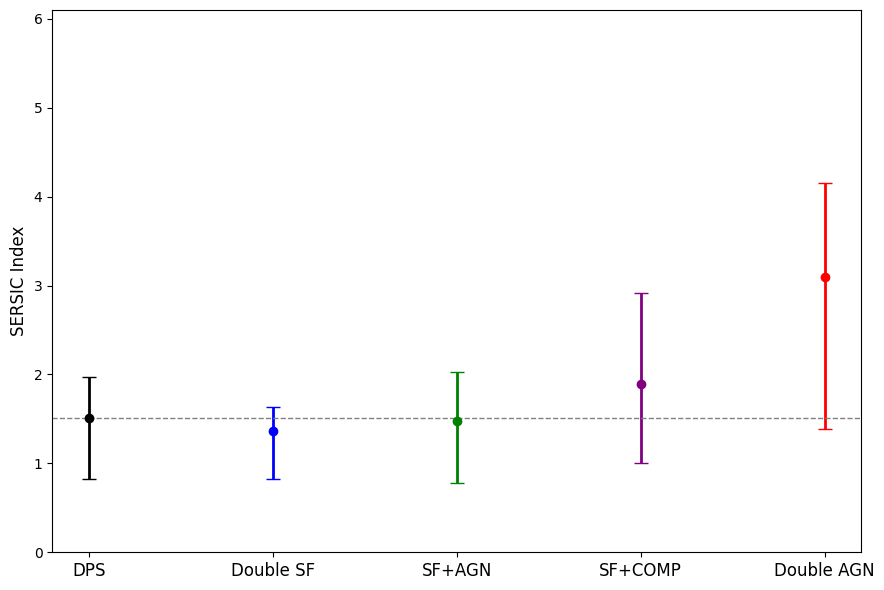

In [123]:
fig, ax = plt.subplots(figsize=(9, 6))

# Data to plot
datasets = [robust_dps, dSF, SF_AGN, SF_COMP, dAGN]
labels = ['DPS', 'Double SF', 'SF+AGN', 'SF+COMP', 'Double AGN']
colors = ['k', 'blue', 'green', 'purple', 'red']

# Calculate means and quantiles for SERSIC index
means = [df['SERSIC'].mean() for df in datasets]
q25 = [df['SERSIC'].quantile(0.2) for df in datasets]
q75 = [df['SERSIC'].quantile(0.8) for df in datasets]

# Calculate asymmetric errors
errors = [np.array([means[i] - q25[i], q75[i] - means[i]]).reshape(2, 1) for i in range(len(datasets))]

# Create the error bar plot
for i, df in enumerate(datasets):
    ax.errorbar(labels[i], means[i], yerr=errors[i], fmt='o', capsize=5, color=colors[i], ecolor=colors[i], elinewidth=2)

# Add some jittered scatter points for visualization
# for i, df in enumerate(datasets):
#     # Generate jitter for x-axis
#     jitter = np.random.normal(0, 0.05, size=len(df))
#     ax.scatter([i + j for j in jitter], df['SERSIC'], alpha=0.01, color=colors[i])
ax.axhline(means[0], color='gray', linestyle='--', linewidth=1)
ax.set_xticklabels(labels=labels, fontsize=12)
ax.set_ylabel('SERSIC Index', fontsize=12)
# ax.set_title('SERSIC Index Distribution by BPT Class', fontsize=14)
ax.set_ylim(bottom=0, top=6.1)
plt.tight_layout()
plt.savefig('./figures/Feb25/SERSIC_by_BPT_class.png')
plt.show()

In [124]:
robust_dps[robust_dps['SERSIC']>4].head(20)

,TARGETID,RA,DEC,Z,LOGM,LOGSFR,dv_r,dv_l,sigma_r,sigma_l,...,dp_count,MORPHTYPE,SERSIC,SHAPE_R,VD_SL,incl,delta_dv,width_ratio,flux_ratio,BPT_class_str
10,39627739388446113,177.554276,-1.971866,0.083630,10.489296,0.985447,7.153632e+01,-36.476711,34.187519,53.084030,...,3,SER,5.204151,1.424334,123.650002,46.709350,108.013031,1.309699,1.575454,SF+COMP
59,39627739422001687,179.589584,-1.983656,0.188073,10.676142,1.441621,1.535183e+02,-64.510422,51.693909,102.733109,...,4,SER,5.744121,1.003499,220.029999,33.157880,218.028702,1.782857,1.625299,COMP+AGN
131,39627739484919966,183.464890,-1.908738,0.241880,10.447141,1.031131,5.474606e+01,-46.558235,41.360004,50.869473,...,6,SER,6.000000,0.658322,62.230000,41.016933,101.304298,1.157781,1.178645,double SF
151,39627739510081481,184.832153,-1.994655,0.131692,10.883685,0.435817,1.106218e+02,-78.526596,44.355080,95.646362,...,4,SER,5.224558,13.624000,140.080002,52.719150,189.148376,1.840113,0.762291,SF+COMP
246,39627739610743754,190.792465,-1.901006,0.118766,9.964684,0.618813,6.161938e+01,-51.635899,30.902929,45.498573,...,6,SER,6.000000,8.394822,80.150002,54.387154,113.255280,1.245658,0.997146,double COMP
317,39627739661078029,193.907593,-1.994841,0.210115,10.571492,1.220360,9.859166e+00,-189.904358,73.689636,329.490021,...,3,SER,6.000000,0.572496,191.630005,23.622742,199.763519,4.154865,0.367165,COMP+AGN
322,39627739673657999,194.528000,-1.879498,0.288526,11.018009,1.502870,1.164168e+02,-133.355270,74.848251,85.970711,...,5,SER,4.392308,1.810741,121.580002,36.186390,249.772095,1.131024,0.792888,double SF
424,39627739753351383,199.346436,-1.955179,0.106683,10.994400,0.165413,9.268068e+01,-71.480698,59.235680,74.402168,...,4,SER,6.000000,8.665271,135.089996,62.175020,164.161377,1.200308,1.098674,double SF
477,39627739791100690,201.636734,-1.883813,0.183866,10.717326,0.258424,1.152866e+01,-63.794193,128.038300,203.230988,...,1,SER,4.514649,0.878542,141.009995,26.912275,75.322853,1.560768,0.217245,AGN+uncertain
482,39627739799486898,202.019196,-1.890129,0.180293,10.764688,-4.672501,2.033923e+02,-194.856537,162.299377,146.382141,...,6,SER,6.000000,1.987401,205.649994,60.036884,398.248840,0.905549,1.131461,double AGN


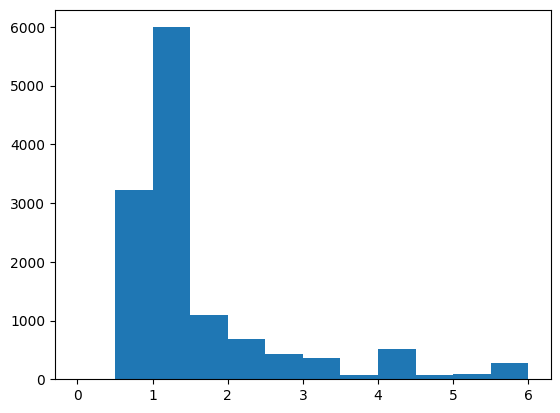

In [125]:
plt.hist(robust_dps['SERSIC'], align='mid', bins=12)
plt.show()

In [126]:
# dAGN = robust_dps[robust_dps['BPT_class_str']=='double AGN']
# print(len(dAGN))
# for i in range(len(dAGN)):
#     ra, dec = dAGN.iloc[i][['RA', 'DEC']]
#     r = dAGN.iloc[i]['SHAPE_R']
#     if r < 1:
#         image_link(ra, dec, side_arcmin=0.3, plot=False, save_image=True, fname=f"./images/{dAGN.iloc[i]['TARGETID']}_image.jpg")
#     else:
#         image_link(ra, dec, side_arcmin=0.5/3*r, plot=False, save_image=True, fname=f"./images/{dAGN.iloc[i]['TARGETID']}_image.jpg")

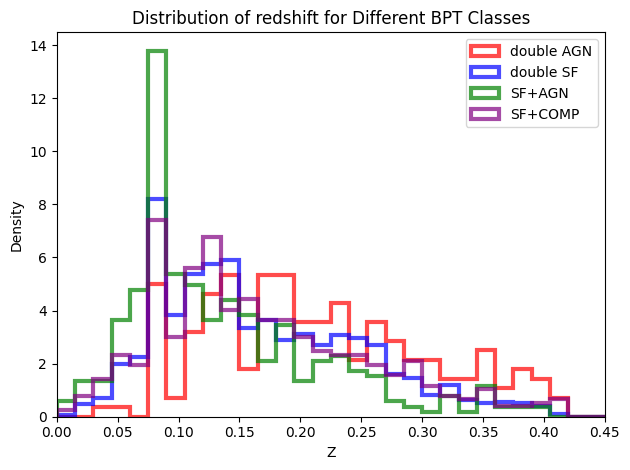

In [127]:
# plt.hist(robust_dps['Z'], bins=30, alpha=0.7, color='gray', histtype='step', label='DPS', range=(8, 12), density=True, linewidth=3)
plt.hist(dAGN['Z'], bins=30, alpha=0.7, color='red', histtype='step', label='double AGN', range=(0, 0.45), density=True, linewidth=3)
plt.hist(dSF['Z'], bins=30, alpha=0.7, color='blue', histtype='step', label='double SF', range=(0, 0.45), density=True, linewidth=3)
plt.hist(SF_AGN['Z'], bins=30, alpha=0.7, color='green', histtype='step', label='SF+AGN', range=(0, 0.45), density=True, linewidth=3)
plt.hist(SF_COMP['Z'], bins=30, alpha=0.7, color='purple', histtype='step', label='SF+COMP', range=(0, 0.45), density=True, linewidth=3)
plt.xlim((0, 0.45))
plt.xlabel('Z')
plt.ylabel('Density')
plt.legend()
plt.title('Distribution of redshift for Different BPT Classes')
plt.tight_layout()
plt.savefig('./figures/Feb25/redshift_distribution.png')
plt.show()

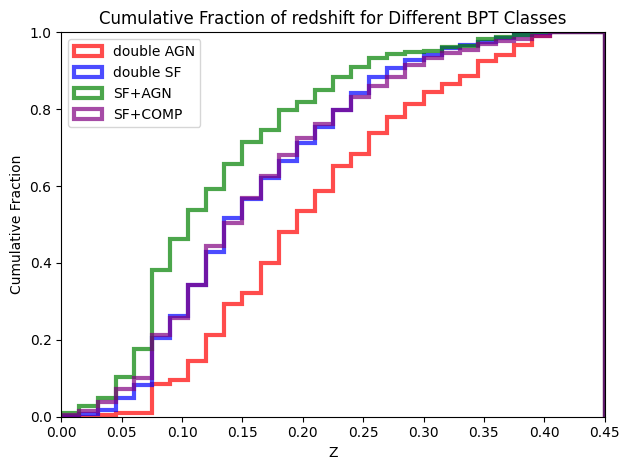

In [128]:
# plt.hist(robust_dps['Z'], bins=30, alpha=0.7, color='gray', histtype='step', label='DPS', range=(8, 12), density=False, linewidth=3)
plt.hist(dAGN['Z'], bins=30, alpha=0.7, color='red', histtype='step', label='double AGN', range=(0, 0.45), density=True, linewidth=3, cumulative=True)
plt.hist(dSF['Z'], bins=30, alpha=0.7, color='blue', histtype='step', label='double SF', range=(0, 0.45), density=True, linewidth=3, cumulative=True)
plt.hist(SF_AGN['Z'], bins=30, alpha=0.7, color='green', histtype='step', label='SF+AGN', range=(0, 0.45), density=True, linewidth=3, cumulative=True)
plt.hist(SF_COMP['Z'], bins=30, alpha=0.7, color='purple', histtype='step', label='SF+COMP', range=(0, 0.45), density=True, linewidth=3, cumulative=True)
plt.xlim((0, 0.45))
plt.ylim((0, 1))
plt.xlabel('Z')
plt.ylabel('Cumulative Fraction')
plt.legend()
plt.title('Cumulative Fraction of redshift for Different BPT Classes')
plt.tight_layout()
plt.savefig('./figures/Feb25/redshift_cumulative_distribution.png')
plt.show()

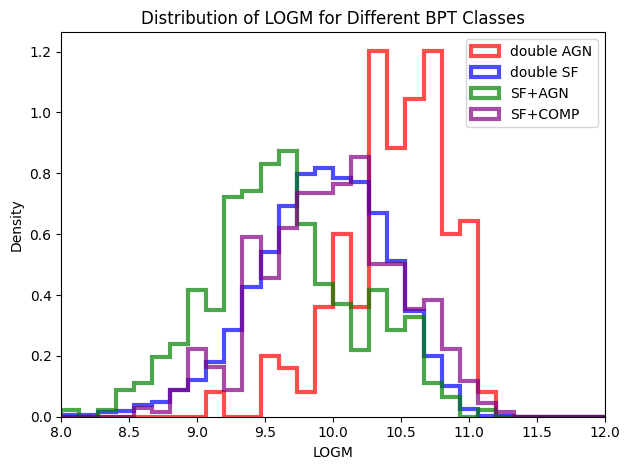

In [129]:
# plt.hist(robust_dps['LOGM'], bins=30, alpha=0.7, color='gray', histtype='step', label='DPS', range=(8, 12), density=True, linewidth=3)
plt.hist(dAGN['LOGM'], bins=30, alpha=0.7, color='red', histtype='step', label='double AGN', range=(8, 12), density=True, linewidth=3)
plt.hist(dSF['LOGM'], bins=30, alpha=0.7, color='blue', histtype='step', label='double SF', range=(8, 12), density=True, linewidth=3)
plt.hist(SF_AGN['LOGM'], bins=30, alpha=0.7, color='green', histtype='step', label='SF+AGN', range=(8, 12), density=True, linewidth=3)
plt.hist(SF_COMP['LOGM'], bins=30, alpha=0.7, color='purple', histtype='step', label='SF+COMP', range=(8, 12), density=True, linewidth=3)
plt.xlim((8, 12))
plt.xlabel('LOGM')
plt.ylabel('Density')
plt.legend()
plt.title('Distribution of LOGM for Different BPT Classes')
plt.tight_layout()
plt.savefig('./figures/Feb25/logm_distribution.png')
plt.show()

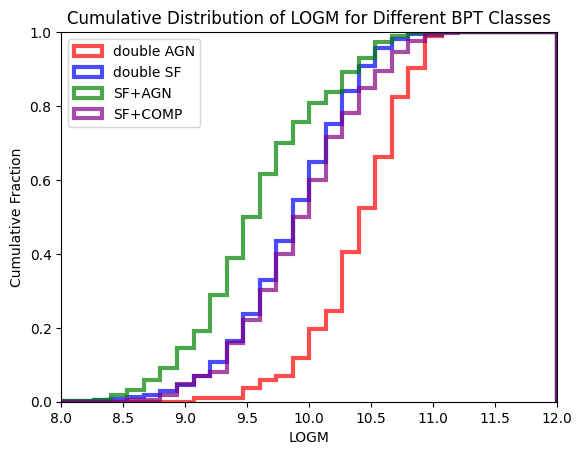

In [130]:
# plt.hist(robust_dps['LOGM'], bins=30, alpha=0.7, color='gray', histtype='step', label='DPS', range=(8, 12), density=True, linewidth=3)
plt.hist(dAGN['LOGM'], bins=30, alpha=0.7, color='red', histtype='step', label='double AGN', range=(8, 12), density=True, linewidth=3, cumulative=True)
plt.hist(dSF['LOGM'], bins=30, alpha=0.7, color='blue', histtype='step', label='double SF', range=(8, 12), density=True, linewidth=3, cumulative=True)
plt.hist(SF_AGN['LOGM'], bins=30, alpha=0.7, color='green', histtype='step', label='SF+AGN', range=(8, 12), density=True, linewidth=3, cumulative=True)
plt.hist(SF_COMP['LOGM'], bins=30, alpha=0.7, color='purple', histtype='step', label='SF+COMP', range=(8, 12), density=True, linewidth=3, cumulative=True)
plt.xlim((8, 12))
plt.ylim((0, 1))
plt.xlabel('LOGM')
plt.ylabel('Cumulative Fraction')
plt.title('Cumulative Distribution of LOGM for Different BPT Classes')
plt.legend()
plt.savefig('./figures/Feb25/logm_cumulative_distribution.png')
plt.show()

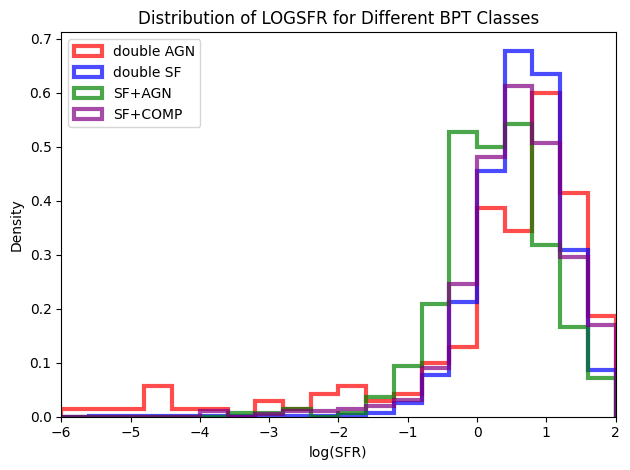

In [131]:
plt.hist(dAGN['LOGSFR'], bins=20, alpha=0.7, color='red', histtype='step', label='double AGN', range=(-6, 2), density=True, linewidth=3)
plt.hist(dSF['LOGSFR'], bins=20, alpha=0.7, color='blue', histtype='step', label='double SF', range=(-6, 2), density=True, linewidth=3)
plt.hist(SF_AGN['LOGSFR'], bins=20, alpha=0.7, color='green', histtype='step', label='SF+AGN', range=(-6, 2), density=True, linewidth=3)
plt.hist(SF_COMP['LOGSFR'], bins=20, alpha=0.7, color='purple', histtype='step', label='SF+COMP', range=(-6, 2), density=True, linewidth=3)
plt.xlim((-6, 2))
plt.xlabel('log(SFR)')
plt.ylabel('Density')
plt.title('Distribution of LOGSFR for Different BPT Classes')
plt.legend()
plt.tight_layout()
plt.savefig('./figures/Feb25/logsfr_distribution.png')
plt.show()

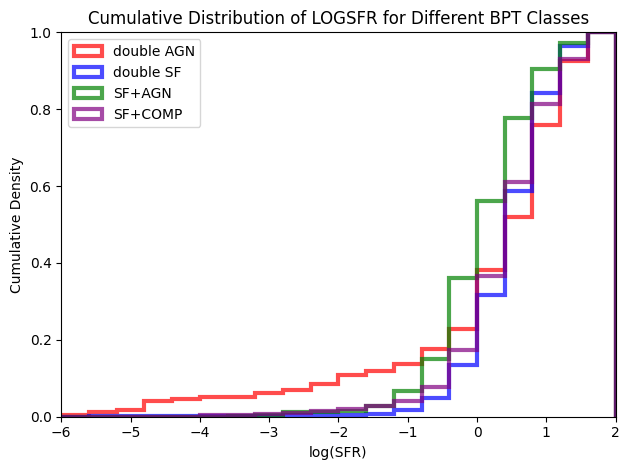

In [132]:
plt.hist(dAGN['LOGSFR'], bins=20, alpha=0.7, color='red', histtype='step', label='double AGN', range=(-6, 2), density=True, linewidth=3, cumulative=True)
plt.hist(dSF['LOGSFR'], bins=20, alpha=0.7, color='blue', histtype='step', label='double SF', range=(-6, 2), density=True, linewidth=3, cumulative=True)
plt.hist(SF_AGN['LOGSFR'], bins=20, alpha=0.7, color='green', histtype='step', label='SF+AGN', range=(-6, 2), density=True, linewidth=3, cumulative=True)
plt.hist(SF_COMP['LOGSFR'], bins=20, alpha=0.7, color='purple', histtype='step', label='SF+COMP', range=(-6, 2), density=True, linewidth=3, cumulative=True)
plt.xlim((-6, 2))
plt.ylim((0, 1))
plt.xlabel('log(SFR)')
plt.ylabel('Cumulative Density')
plt.legend()
plt.title('Cumulative Distribution of LOGSFR for Different BPT Classes')
plt.tight_layout()
plt.savefig('./figures/Feb25/logsfr_cumulative_distribution.png')
plt.show()

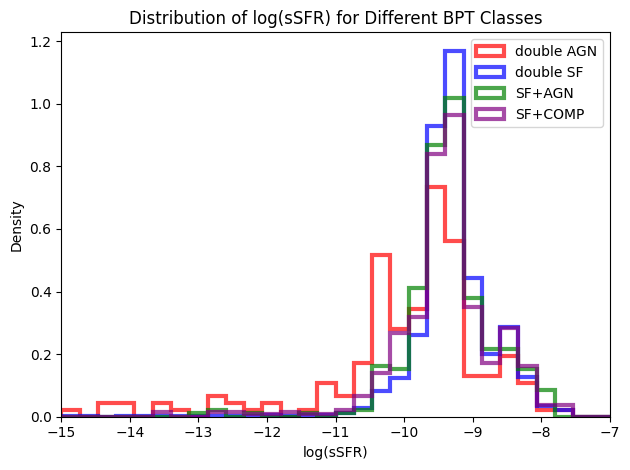

In [133]:
plt.hist(dAGN['LOGSFR']-dAGN['LOGM'], bins=30, alpha=0.7, color='red', histtype='step', label='double AGN', range=(-15,-7), density=True, linewidth=3)
plt.hist(dSF['LOGSFR']-dSF['LOGM'], bins=30, alpha=0.7, color='blue', histtype='step', label='double SF', range=(-15, -7), density=True, linewidth=3)
plt.hist(SF_AGN['LOGSFR']-SF_AGN['LOGM'], bins=30, alpha=0.7, color='green', histtype='step', label='SF+AGN', range=(-15, -7), density=True, linewidth=3)
plt.hist(SF_COMP['LOGSFR']-SF_COMP['LOGM'], bins=30, alpha=0.7, color='purple', histtype='step', label='SF+COMP', range=(-15, -7), density=True, linewidth=3)
plt.xlim((-15, -7))
plt.xlabel('log(sSFR)')
plt.ylabel('Density')
plt.legend()
plt.title('Distribution of log(sSFR) for Different BPT Classes')
plt.tight_layout()
plt.savefig('./figures/Feb25/logssfr_distribution.png')
plt.show()

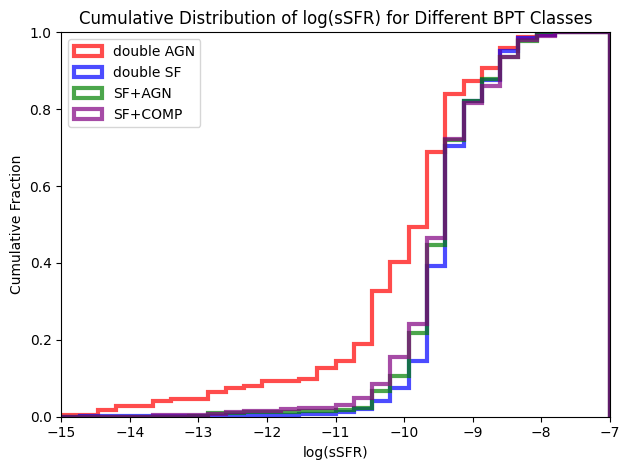

In [134]:
plt.hist(dAGN['LOGSFR']-dAGN['LOGM'], bins=30, alpha=0.7, color='red', histtype='step', label='double AGN', range=(-15,-7), density=True, linewidth=3, cumulative=True)
plt.hist(dSF['LOGSFR']-dSF['LOGM'], bins=30, alpha=0.7, color='blue', histtype='step', label='double SF', range=(-15, -7), density=True, linewidth=3, cumulative=True)
plt.hist(SF_AGN['LOGSFR']-SF_AGN['LOGM'], bins=30, alpha=0.7, color='green', histtype='step', label='SF+AGN', range=(-15, -7), density=True, linewidth=3, cumulative=True)
plt.hist(SF_COMP['LOGSFR']-SF_COMP['LOGM'], bins=30, alpha=0.7, color='purple', histtype='step', label='SF+COMP', range=(-15, -7), density=True, linewidth=3, cumulative=True)
plt.xlim((-15, -7))
plt.ylim((0, 1))
plt.xlabel('log(sSFR)')
plt.ylabel('Cumulative Fraction')
plt.legend()
plt.title('Cumulative Distribution of log(sSFR) for Different BPT Classes')
plt.tight_layout()
plt.savefig('./figures/Feb25/logssfr_cumulative_distribution.png')
plt.show()

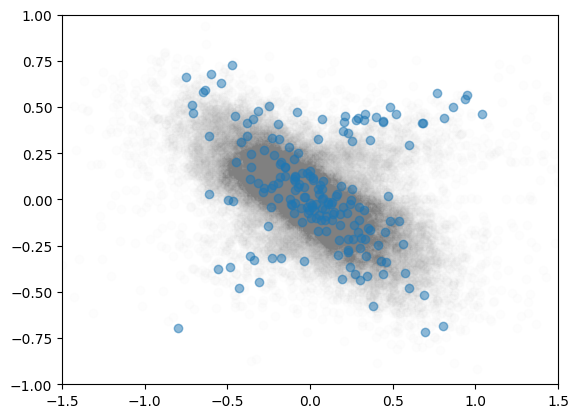

In [135]:
Mr_Ml_ratio = np.log10(-dAGN['dv_l']/dAGN['dv_r'])
plt.scatter((np.log10(-dps_df['dv_l']/(dps_df['dv_r']))), (np.log10(dps_df['width_ratio'])), alpha=0.01, color='gray')
plt.scatter((Mr_Ml_ratio), (np.log10(dAGN['width_ratio'])), alpha=0.5)
plt.xlim((-1.5, 1.5))
plt.ylim((-1, 1))
plt.show()